In [1]:
"""
2026-04-10 MY testing the results


"""

from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import geopandas as gpd

import re
from pathlib import Path

import numpy as np
import rasterio
from rasterio.plot import plotting_extent
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# python
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import plotting_extent
import rasterio

trade_path = Path('/Users/myliheik/Documents/myPython/FAOSTAT_trade/data/intermediate/trade_export_quantity_t_1992_2020.csv')
ne_path = Path('/Users/myliheik/Documents/myPython/FAOSTAT_trade/data/gis/adm0_NatEarth_all_ids.shp')

trade = pd.read_csv(trade_path, low_memory=False)
ne = gpd.read_file(ne_path)



# FAOSTAT Export Quantity Time Series
Plot annual export quantity for selected countries and `lu_class`.

In [2]:
trade.head()

,Area Code (M49),Year,lu_class,group_sum,ISOA3
0,'004,1992,CL-OOIL,500.0,AFG
1,'004,1992,CL-POTA,0.0,AFG
2,'004,1992,CL-REST,875.0,AFG
3,'004,1992,CL-VEFR,16560.0,AFG
4,'004,1993,CL-OOIL,1200.0,AFG


In [3]:

def find_col(df, candidates):
    cols = list(df.columns)
    low = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in low:
            return low[cand.lower()]
    for cand in candidates:
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

iso_col_trade = find_col(trade, ['ISOA3', 'iso_a3', 'Area Code (ISO3)'])
year_col = find_col(trade, ['Year', 'year'])
value_col = find_col(trade, ['group_sum', 'Value', 'value'])
lu_col = find_col(trade, ['lu_class', 'LU_CLASS'])

iso_col_ne = find_col(ne, ['iso_a3', 'ISO_A3', 'ISO3'])
name_col_ne = find_col(ne, ['name', 'NAME', 'ADMIN', 'SOVEREIGNT'])

countries = ['ZAF', 'FRA', 'UKR']
lu_target = 'CL-WHEA'

plot_df = (
    trade.loc[
        (trade[lu_col] == lu_target) &
        (trade[iso_col_trade].isin(countries)),
        [iso_col_trade, year_col, value_col]
    ]
    .copy()
)

plot_df[year_col] = pd.to_numeric(plot_df[year_col], errors='coerce')
plot_df[value_col] = pd.to_numeric(plot_df[value_col], errors='coerce')

country_lookup = ne[[iso_col_ne, name_col_ne]].drop_duplicates()
plot_df = plot_df.merge(country_lookup, how='left', left_on=iso_col_trade, right_on=iso_col_ne)
plot_df = plot_df.sort_values([iso_col_trade, year_col])

plot_df.head()

,ISOA3,Year,group_sum,iso_a3,admin
0,FRA,1992,17355168.0,FRA,France
1,FRA,1993,18259094.0,FRA,France
2,FRA,1994,12650000.0,FRA,France
3,FRA,1995,16310000.0,FRA,France
4,FRA,1996,14550000.0,FRA,France


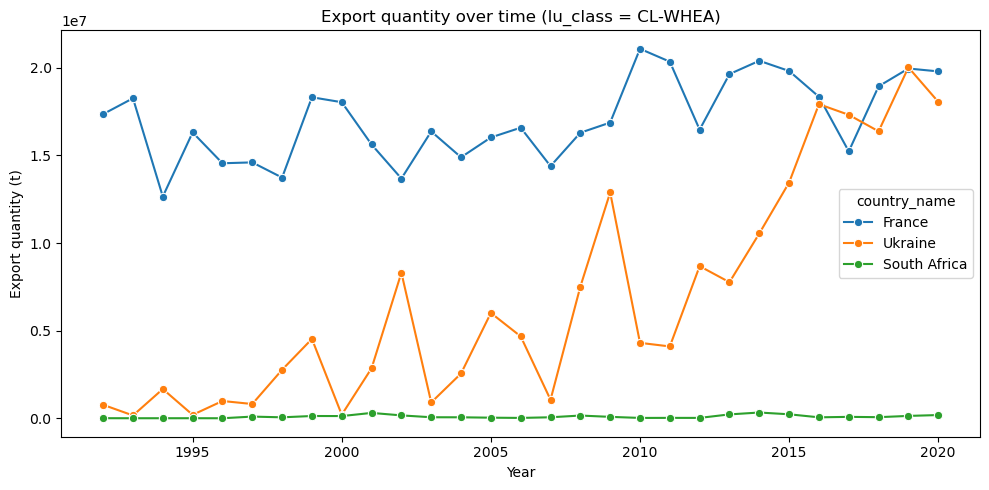

In [4]:
plot_data = plot_df.rename(columns={name_col_ne: 'country_name'})

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=plot_data,
    x=year_col,
    y=value_col,
    hue='country_name',
    marker='o'
)
plt.title(f'Export quantity over time (lu_class = {lu_target})')
plt.xlabel('Year')
plt.ylabel('Export quantity (t)')
plt.tight_layout()
plt.show()

In [5]:
trade['lu_class'].unique()

array(['CL-OOIL', 'CL-POTA', 'CL-REST', 'CL-VEFR', 'CL-MAIZ', 'CL-BANP',
       'CL-BEAN', 'CL-GROU', 'CL-OPUL', 'CL-SWPY', 'CL-WHEA', 'CL-SOYB',
       'CL-SUGB', 'CL-BARL', 'CL-RICE', 'CL-OFIB', 'CL-SORG', 'CL-SUGC',
       'CL-MILL', 'CL-COFF', 'CL-CASS'], dtype=object)

In [6]:
plot_df

,ISOA3,Year,group_sum,iso_a3,admin
0,FRA,1992,17355168.00,FRA,France
1,FRA,1993,18259094.00,FRA,France
2,FRA,1994,12650000.00,FRA,France
3,FRA,1995,16310000.00,FRA,France
4,FRA,1996,14550000.00,FRA,France
...,...,...,...,...,...
53,ZAF,2016,52557.48,ZAF,South Africa
54,ZAF,2017,79124.91,ZAF,South Africa
55,ZAF,2018,61327.40,ZAF,South Africa
56,ZAF,2019,133394.04,ZAF,South Africa


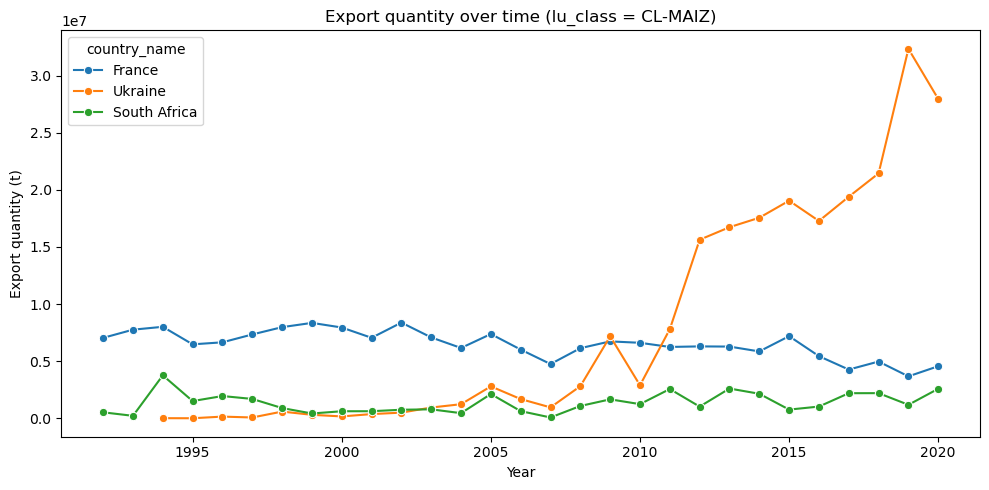

,ISOA3,Year,group_sum,iso_a3,country_name
0,FRA,1992,7042037.00,FRA,France
1,FRA,1993,7757947.00,FRA,France
2,FRA,1994,8009524.00,FRA,France
3,FRA,1995,6474138.00,FRA,France
4,FRA,1996,6651967.00,FRA,France
...,...,...,...,...,...
53,ZAF,2016,1026609.20,ZAF,South Africa
54,ZAF,2017,2197086.61,ZAF,South Africa
55,ZAF,2018,2201307.44,ZAF,South Africa
56,ZAF,2019,1180771.96,ZAF,South Africa


In [7]:

countries = ['ZAF', 'FRA', 'UKR']
lu_target = 'CL-MAIZ'

plot_df = (
    trade.loc[
        (trade[lu_col] == lu_target) &
        (trade[iso_col_trade].isin(countries)),
        [iso_col_trade, year_col, value_col]
    ]
    .copy()
)

plot_df[year_col] = pd.to_numeric(plot_df[year_col], errors='coerce')
plot_df[value_col] = pd.to_numeric(plot_df[value_col], errors='coerce')

country_lookup = ne[[iso_col_ne, name_col_ne]].drop_duplicates()
plot_df = plot_df.merge(country_lookup, how='left', left_on=iso_col_trade, right_on=iso_col_ne)
plot_df = plot_df.sort_values([iso_col_trade, year_col])

plot_data = plot_df.rename(columns={name_col_ne: 'country_name'})

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=plot_data,
    x=year_col,
    y=value_col,
    hue='country_name',
    marker='o'
)
plt.title(f'Export quantity over time (lu_class = {lu_target})')
plt.xlabel('Year')
plt.ylabel('Export quantity (t)')
plt.tight_layout()
plt.show()

plot_data

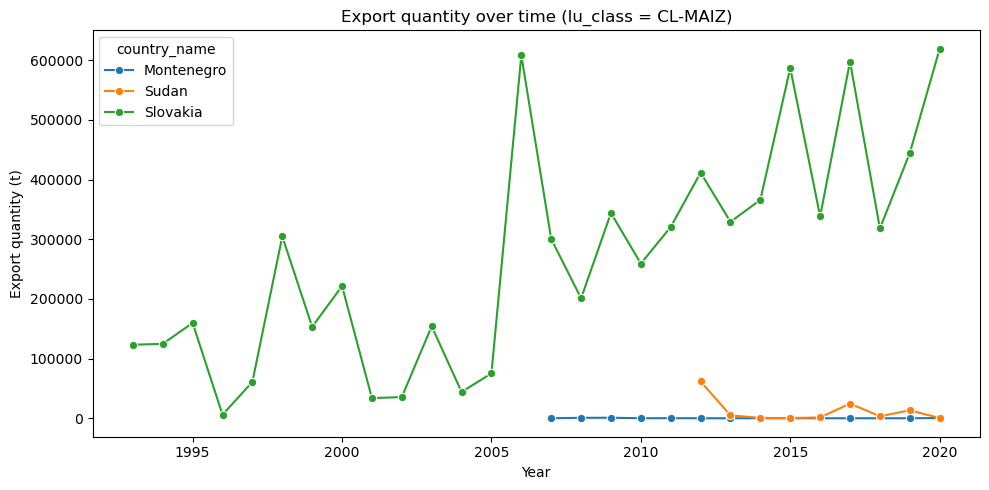

In [8]:
# let's plot the potential pitfalls:

countries = ['MNE', 'SDN', 'SVK']
lu_target = 'CL-MAIZ'

plot_df = (
    trade.loc[
        (trade[lu_col] == lu_target) &
        (trade[iso_col_trade].isin(countries)),
        [iso_col_trade, year_col, value_col]
    ]
    .copy()
)

plot_df[year_col] = pd.to_numeric(plot_df[year_col], errors='coerce')
plot_df[value_col] = pd.to_numeric(plot_df[value_col], errors='coerce')

country_lookup = ne[[iso_col_ne, name_col_ne]].drop_duplicates()
plot_df = plot_df.merge(country_lookup, how='left', left_on=iso_col_trade, right_on=iso_col_ne)
plot_df = plot_df.sort_values([iso_col_trade, year_col])

plot_data = plot_df.rename(columns={name_col_ne: 'country_name'})

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=plot_data,
    x=year_col,
    y=value_col,
    hue='country_name',
    marker='o'
)
plt.title(f'Export quantity over time (lu_class = {lu_target})')
plt.xlabel('Year')
plt.ylabel('Export quantity (t)')
plt.tight_layout()
plt.show()

Year,ISOA3,export_1992,export_2020,export_diff_2020_1992
0,AFG,NaN,215.03,NaN
1,AGO,0.0,19.30,19.30
2,ALB,0.0,NaN,NaN
3,ARE,756.0,71929.21,71173.21
4,ARG,6092827.0,36881995.76,30789168.76
...,...,...,...,...
147,VUT,0.0,NaN,NaN
148,YEM,0.0,12491.68,12491.68
149,ZAF,523750.0,2584946.46,2061196.46
150,ZMB,115.0,59379.77,59264.77


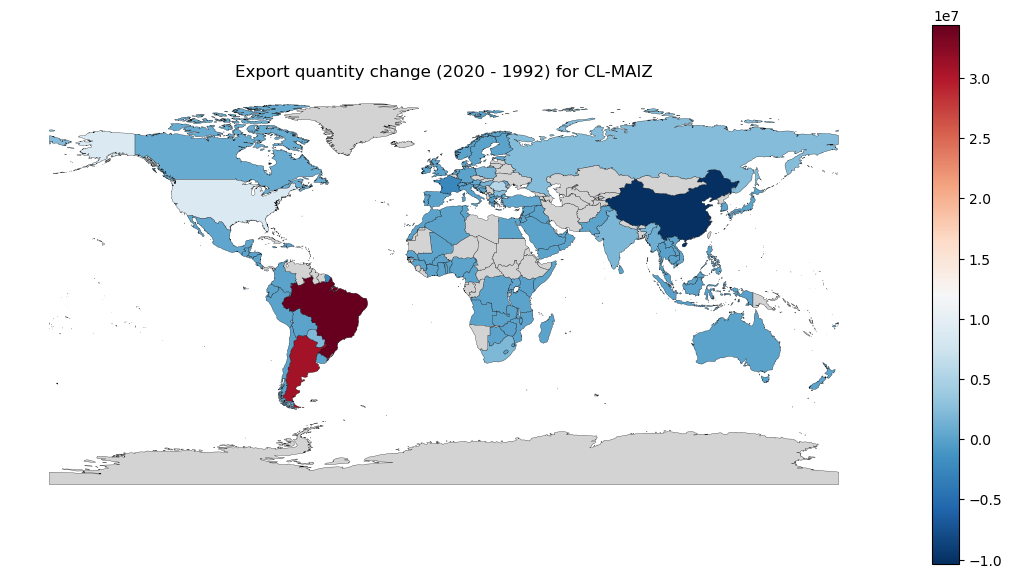

In [9]:
# language: python
import numpy as np

year_a, year_b = 1992, 2020

# use detected columns from earlier cells
base = trade[[iso_col_trade, year_col, value_col, lu_col]].copy()
base[year_col] = pd.to_numeric(base[year_col], errors="coerce")
base[value_col] = pd.to_numeric(base[value_col], errors="coerce")

# keep one lu_class (remove this filter line if you want all lu_class combined)
base = base.loc[base[lu_col] == lu_target]

# keep only the two years, aggregate by country-year
agg = (
    base.loc[base[year_col].isin([year_a, year_b])]
    .groupby([iso_col_trade, year_col], as_index=False)[value_col]
    .sum(min_count=1)
)

# reshape to wide and compute difference
wide = agg.pivot(index=iso_col_trade, columns=year_col, values=value_col).reset_index()
for y in [year_a, year_b]:
    if y not in wide.columns:
        wide[y] = np.nan

diff_df = (
    wide.assign(export_diff_2020_1992=wide[year_b] - wide[year_a])
    .rename(columns={iso_col_trade: "ISOA3", year_a: f"export_{year_a}", year_b: f"export_{year_b}"})
)

# merge to Natural Earth and plot
world_diff = ne.merge(diff_df, how="left", left_on=iso_col_ne, right_on="ISOA3")

ax = world_diff.plot(
    column="export_diff_2020_1992",
    cmap="RdBu_r",
    legend=True,
    figsize=(14, 7),
    missing_kwds={"color": "lightgrey", "label": "No data"},
    linewidth=0.2,
    edgecolor="black",
)
ax.set_title(f"Export quantity change ({year_b} - {year_a}) for {lu_target}")
ax.set_axis_off()

diff_df

# FAOSTAT Export Quantity Time Series from data cube
Can we reproduce the same from data cubes?

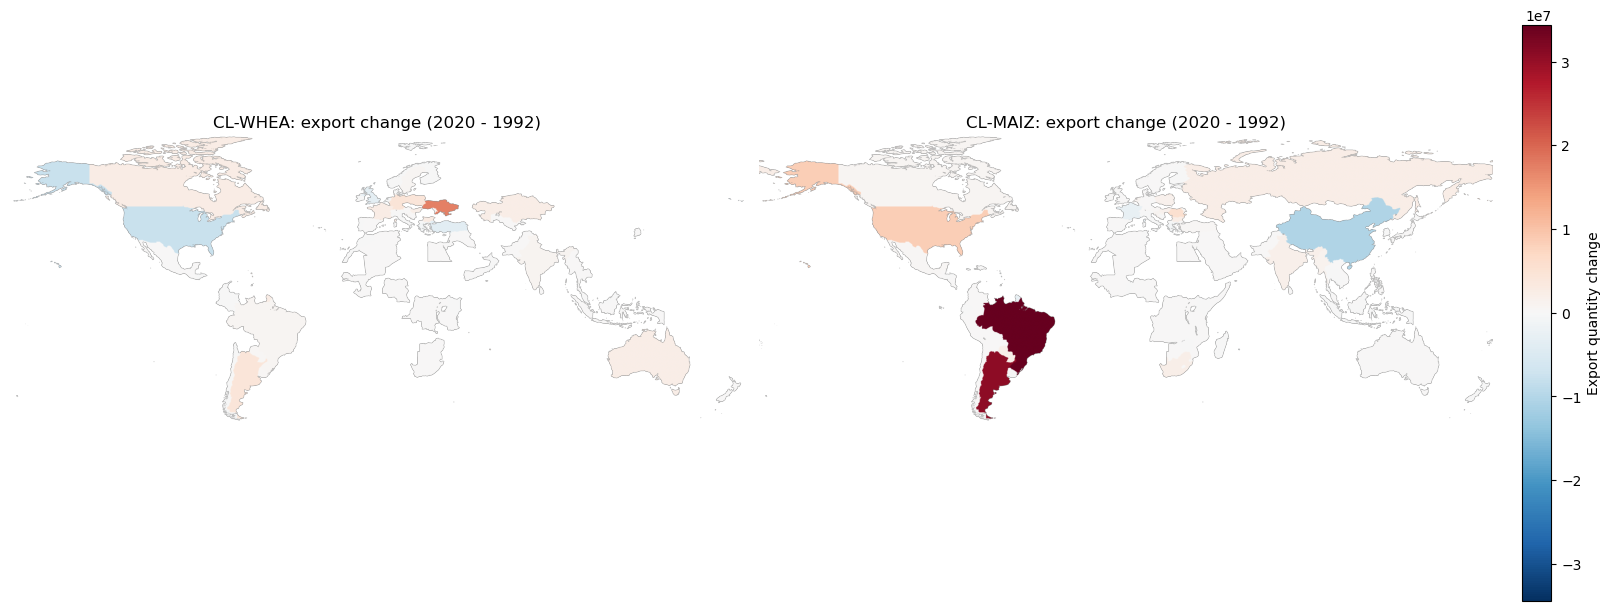

In [10]:


output_dir = Path("/Users/myliheik/Documents/myPython/FAOSTAT_trade/data/output")
year_a, year_b = 1992, 2020
lu_classes = ["CL-WHEA", "CL-MAIZ"]


def _read_band_for_year_from_cube(tif_path: Path, year: int) -> tuple[np.ndarray, dict]:
    with rasterio.open(tif_path) as src:
        desc = [d.strip() if isinstance(d, str) else None for d in src.descriptions]

        # 1) Try band descriptions (e.g. "1992", "1993", ...)
        if any(desc):
            year_str = str(year)
            if year_str in desc:
                band_idx = desc.index(year_str) + 1
                arr = src.read(band_idx).astype("float32")
                return arr, src.meta

        # 2) Fallback: infer start/end from filename and use positional band
        m = re.search(r"(19|20)\d{2}_(19|20)\d{2}", tif_path.stem)
        if not m:
            raise ValueError(f"Cannot infer year bands from file: {tif_path.name}")

        y0, y1 = map(int, m.group(0).split("_"))
        if not (y0 <= year <= y1):
            raise ValueError(f"Year {year} not covered by cube: {tif_path.name}")

        band_idx = (year - y0) + 1
        if band_idx < 1 or band_idx > src.count:
            raise ValueError(f"Band index out of range for {tif_path.name}")

        arr = src.read(band_idx).astype("float32")
        return arr, src.meta


def _read_year_from_single_band_files(lu_class: str, year: int) -> tuple[np.ndarray, dict]:
    # finds files containing lu_class and year in filename
    candidates = sorted(output_dir.glob(f"trade_export_quantity*{lu_class}*{year}*.tif"))
    if not candidates:
        raise FileNotFoundError(f"No raster found for {lu_class}, year {year} in {output_dir}")
    tif_path = candidates[0]
    with rasterio.open(tif_path) as src:
        arr = src.read(1).astype("float32")
        return arr, src.meta


def read_lu_year(lu_class: str, year: int) -> tuple[np.ndarray, dict]:
    # Prefer cube file first
    cube_candidates = sorted(output_dir.glob(f"*{lu_class}*cube*.tif"))
    if cube_candidates:
        return _read_band_for_year_from_cube(cube_candidates[0], year)

    # Fallback to yearly single-band files
    return _read_year_from_single_band_files(lu_class, year)


def compute_change_map(lu_class: str, y0: int, y1: int) -> tuple[np.ndarray, dict]:
    a0, meta0 = read_lu_year(lu_class, y0)
    a1, meta1 = read_lu_year(lu_class, y1)

    if a0.shape != a1.shape:
        raise ValueError(f"Shape mismatch for {lu_class}: {a0.shape} vs {a1.shape}")

    nod0 = meta0.get("nodata")
    nod1 = meta1.get("nodata")
    if nod0 is not None:
        a0 = np.where(a0 == nod0, np.nan, a0)
    if nod1 is not None:
        a1 = np.where(a1 == nod1, np.nan, a1)

    diff = a1 - a0
    return diff, meta1


# build change rasters
diff_maps = {}
metas = {}
for lu in lu_classes:
    diff_maps[lu], metas[lu] = compute_change_map(lu, year_a, year_b)

# shared symmetric color scale around 0
all_vals = np.concatenate([np.ravel(diff_maps[lu]) for lu in lu_classes])
v = np.nanpercentile(np.abs(all_vals), 99)  # robust max
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

# plot
fig, axes = plt.subplots(1, len(lu_classes), figsize=(16, 6), constrained_layout=True)
if len(lu_classes) == 1:
    axes = [axes]

for ax, lu in zip(axes, lu_classes):
    with rasterio.open(next(output_dir.glob(f"*{lu}*.tif"))) as src_ref:
        extent = plotting_extent(src_ref)

    im = ax.imshow(diff_maps[lu], cmap="RdBu_r", norm=norm, extent=extent, origin="upper")
    ax.set_title(f"{lu}: export change ({year_b} - {year_a})")
    ax.set_axis_off()

cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label("Export quantity change")


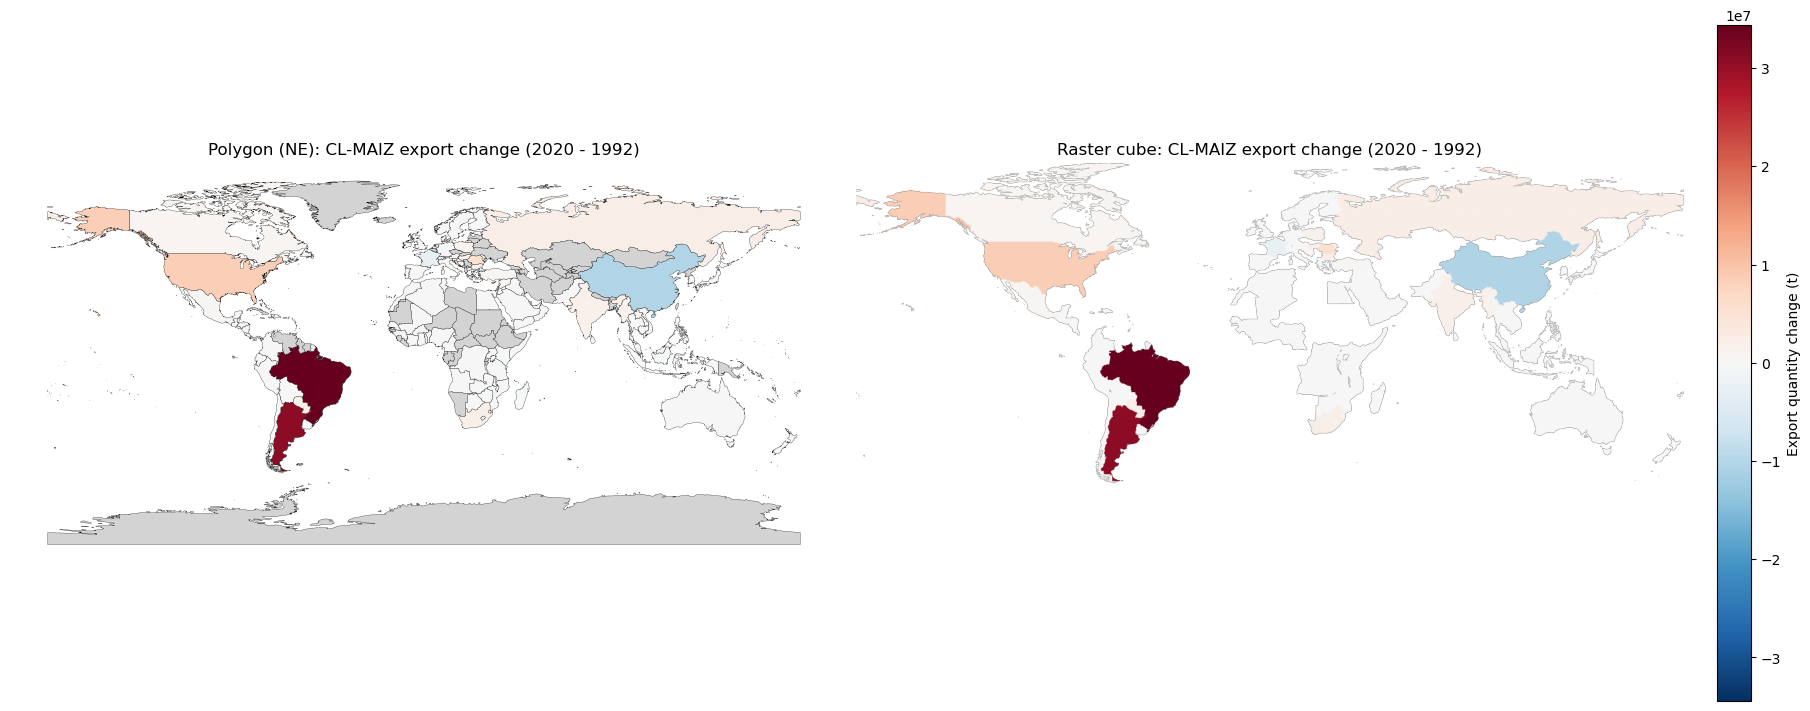

In [11]:


# --- settings ---
lu_target = "CL-MAIZ"
year_a, year_b = 1992, 2020

# --- polygon-based MAIZ difference ---
base = trade[[iso_col_trade, year_col, value_col, lu_col]].copy()
base[year_col] = pd.to_numeric(base[year_col], errors="coerce")
base[value_col] = pd.to_numeric(base[value_col], errors="coerce")
base = base.loc[base[lu_col] == lu_target]

agg = (
    base.loc[base[year_col].isin([year_a, year_b])]
    .groupby([iso_col_trade, year_col], as_index=False)[value_col]
    .sum(min_count=1)
)

wide = agg.pivot(index=iso_col_trade, columns=year_col, values=value_col).reset_index()
for y in [year_a, year_b]:
    if y not in wide.columns:
        wide[y] = np.nan

diff_df_maiz = (
    wide.assign(export_diff_2020_1992=wide[year_b] - wide[year_a])
    .rename(columns={iso_col_trade: "ISOA3"})
)

world_diff_maiz = ne.merge(diff_df_maiz, how="left", left_on=iso_col_ne, right_on="ISOA3")

# --- raster-based MAIZ difference ---
if "CL-MAIZ" in diff_maps:
    raster_diff_maiz = diff_maps["CL-MAIZ"]
else:
    raster_diff_maiz, _ = compute_change_map("CL-MAIZ", year_a, year_b)

with rasterio.open(next(output_dir.glob("*CL-MAIZ*.tif"))) as src_ref:
    extent_maiz = plotting_extent(src_ref)

# --- shared color normalization across both maps ---
poly_vals = world_diff_maiz["export_diff_2020_1992"].to_numpy(dtype=float)
rast_vals = raster_diff_maiz.astype(float).ravel()
all_vals = np.concatenate([poly_vals[~np.isnan(poly_vals)], rast_vals[~np.isnan(rast_vals)]])
v = np.nanpercentile(np.abs(all_vals), 99)
norm_shared = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)

# --- side-by-side plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

world_diff_maiz.plot(
    column="export_diff_2020_1992",
    cmap="RdBu_r",
    norm=norm_shared,
    legend=False,
    ax=ax1,
    missing_kwds={"color": "lightgrey"},
    linewidth=0.2,
    edgecolor="black",
)
ax1.set_title(f"Polygon (NE): {lu_target} export change ({year_b} - {year_a})")
ax1.set_axis_off()

im = ax2.imshow(
    raster_diff_maiz,
    cmap="RdBu_r",
    norm=norm_shared,
    extent=extent_maiz,
    origin="upper",
)
ax2.set_title(f"Raster cube: {lu_target} export change ({year_b} - {year_a})")
ax2.set_axis_off()

cbar = fig.colorbar(im, ax=[ax1, ax2], fraction=0.03, pad=0.02)
cbar.set_label("Export quantity change (t)")

In [12]:
# ok, so we are missing some years, like for Ukraine year 1992. Interpolate missing values.